# Geneformer: final test loss vs. MI

For every `(dataset, size, quality)` Geneformer run on disk we pull:
- **final test loss** from `results/Geneformer/model/test_loss.txt`
- **MI** from `results/Geneformer/model/MI/<seed>/Y_<signal>_<quality>_geneformer/lmi_mutual_information.txt` (averaged over the 4 LMI seeds).

One point per `(size, quality, signal)`. Columns split by dataset/signal; color encodes quality.

In [21]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

DATA_ROOT = Path('/home/igor/noise_scaling/data')
DATASETS = ['PBMC', 'larry', 'merfish', 'shendure']
MI_SEEDS = [42]  # seed 42 only

_SIGNAL_RE = re.compile(r'^Y_(?P<signal>.+)_(?P<q>[0-9.]+)_geneformer$')

In [22]:
def _is_size_dir(p: Path) -> bool:
    return p.is_dir() and p.name.isdigit()

def _is_quality_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    try:
        float(p.name); return True
    except ValueError:
        return False

def _read_float(path: Path):
    try:
        return float(path.read_text().strip())
    except Exception:
        return None

def _mi_for_run(model_dir: Path) -> dict[str, float]:
    # signal -> mean MI across seeds
    mi_dir = model_dir / 'MI'
    if not mi_dir.is_dir():
        return {}
    per_signal: dict[str, list[float]] = {}
    for seed in MI_SEEDS:
        seed_dir = mi_dir / str(seed)
        if not seed_dir.is_dir():
            continue
        for sig_dir in seed_dir.iterdir():
            m = _SIGNAL_RE.match(sig_dir.name)
            if not m:
                continue
            v = _read_float(sig_dir / 'lmi_mutual_information.txt')
            if v is None or not np.isfinite(v):
                continue
            per_signal.setdefault(m.group('signal'), []).append(v)
    return {s: float(np.mean(vs)) for s, vs in per_signal.items() if vs}

rows = []
for ds in DATASETS:
    ds_dir = DATA_ROOT / ds
    if not ds_dir.is_dir():
        continue
    for size_dir in sorted(filter(_is_size_dir, ds_dir.iterdir()), key=lambda p: int(p.name)):
        size = int(size_dir.name)
        for q_dir in sorted(filter(_is_quality_dir, size_dir.iterdir()), key=lambda p: float(p.name)):
            q = float(q_dir.name)
            model_dir = q_dir / 'results' / 'Geneformer' / 'model'
            test_loss = _read_float(model_dir / 'test_loss.txt')
            if test_loss is None:
                continue
            mi_by_signal = _mi_for_run(model_dir)
            if not mi_by_signal:
                continue
            for signal, mi in mi_by_signal.items():
                rows.append({
                    'dataset': ds, 'size': size, 'quality': q,
                    'signal': signal, 'mi': mi, 'test_loss': test_loss,
                })

df = (pd.DataFrame(rows)
        .sort_values(['dataset', 'signal', 'size', 'quality'])
        .reset_index(drop=True))
print(f'Loaded {len(df)} points across {df["dataset"].nunique()} datasets, '
      f'{df.groupby(["dataset","signal"]).ngroups} (dataset, signal) panels')
display(df.head())

Loaded 496 points across 4 datasets, 5 (dataset, signal) panels


,dataset,size,quality,signal,mi,test_loss
0,PBMC,100,0.001235,celltype.l3,0.40001,8.591434
1,PBMC,100,0.002598,celltype.l3,0.75504,8.490328
2,PBMC,100,0.005468,celltype.l3,1.08017,8.066418
3,PBMC,100,0.011508,celltype.l3,1.37634,7.649487
4,PBMC,100,0.024220,celltype.l3,1.71691,7.342809


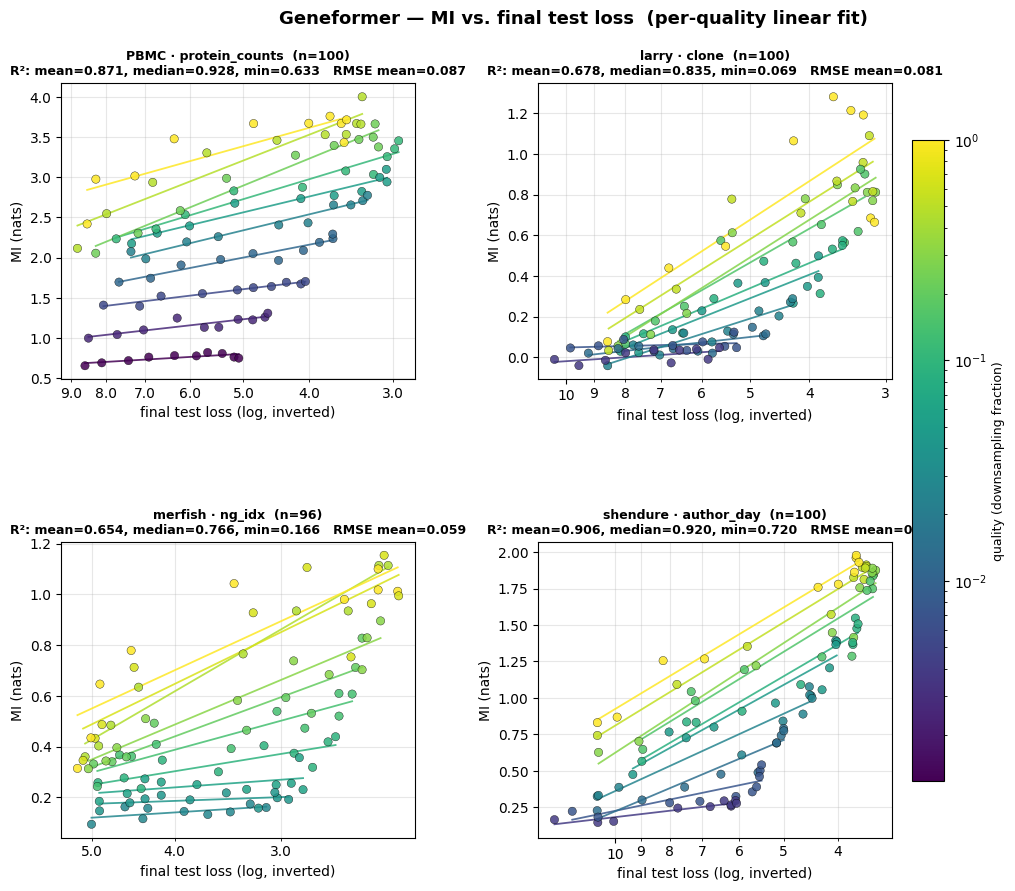


Computed 40 per-quality linear fits across 4 panels.


In [23]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter
from scipy import stats

# Drop celltype.l3 for PBMC — keep protein_counts so each dataset is a single panel.
df_plot = df[~((df['dataset'] == 'PBMC') & (df['signal'] == 'celltype.l3'))].copy()

panels = (df_plot.groupby(['dataset', 'signal'])
                 .size().reset_index(name='n')
                 .sort_values(['dataset', 'signal']).reset_index(drop=True))

# Per-quality linear fit metrics:
#   slope, intercept, R² (Pearson), p-value, RMSE of residuals, slope SE, n.
fit_rows = []

if panels.empty:
    print('No Geneformer runs with both test_loss and MI found.')
else:
    nrows, ncols = 2, 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols + 1.4, 4.6 * nrows),
                             squeeze=False)
    fig.subplots_adjust(wspace=0.35, hspace=0.55, left=0.08, right=0.9,
                        top=0.90, bottom=0.08)
    cmap = plt.cm.viridis
    qnorm = mcolors.LogNorm(vmin=df_plot['quality'].min(), vmax=df_plot['quality'].max())

    for idx, row in panels.iterrows():
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        sub = df_plot[(df_plot['dataset'] == row['dataset']) & (df_plot['signal'] == row['signal'])]
        ax.scatter(sub['test_loss'], sub['mi'],
                   c=cmap(qnorm(sub['quality'].values)),
                   s=36, edgecolor='k', linewidth=0.3, alpha=0.85, zorder=3)

        panel_r2, panel_rmse = [], []
        for q, g in sub.groupby('quality'):
            if len(g) < 2:
                continue
            color = cmap(qnorm(q))
            x = np.log10(g['test_loss'].values)
            y = g['mi'].values
            reg = stats.linregress(x, y)
            y_hat = reg.slope * x + reg.intercept
            rmse = float(np.sqrt(np.mean((y - y_hat) ** 2)))
            r2 = float(reg.rvalue ** 2)

            xx = np.linspace(x.min(), x.max(), 50)
            ax.plot(10 ** xx, reg.slope * xx + reg.intercept, color=color,
                    linewidth=1.3, alpha=0.85, zorder=2)

            fit_rows.append({
                'dataset': row['dataset'], 'signal': row['signal'],
                'quality': float(q), 'n': int(len(g)),
                'slope': float(reg.slope), 'intercept': float(reg.intercept),
                'R2': r2, 'p_value': float(reg.pvalue),
                'RMSE': rmse, 'slope_SE': float(reg.stderr),
            })
            panel_r2.append(r2); panel_rmse.append(rmse)

        ax.set_xscale('log')
        ax.invert_xaxis()
        fmt = ScalarFormatter(); fmt.set_scientific(False)
        ax.xaxis.set_major_formatter(fmt); ax.xaxis.set_minor_formatter(fmt)
        ax.set_xlabel('final test loss (log, inverted)')
        ax.set_ylabel('MI (nats)')

        if panel_r2:
            title = (f"{row['dataset']} · {row['signal']}  (n={row['n']})\n"
                     f"R²: mean={np.mean(panel_r2):.3f}, "
                     f"median={np.median(panel_r2):.3f}, "
                     f"min={np.min(panel_r2):.3f}   "
                     f"RMSE mean={np.mean(panel_rmse):.3f}")
        else:
            title = f"{row['dataset']} · {row['signal']}  (n={row['n']})"
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3, which='both')

    for k in range(len(panels), nrows * ncols):
        r, c = divmod(k, ncols)
        axes[r, c].axis('off')

    sm = plt.cm.ScalarMappable(norm=qnorm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
    cbar.set_label('quality (downsampling fraction)', fontsize=9)

    fig.suptitle('Geneformer — MI vs. final test loss  (per-quality linear fit)',
                 fontsize=13, fontweight='bold')
    plt.show()

fits_df = pd.DataFrame(fit_rows)
print(f'\nComputed {len(fits_df)} per-quality linear fits across {len(panels)} panels.')

### Fit-quality table

For each `(dataset, signal, quality)` linear fit we report:

- **R²** — fraction of MI variance explained by the log-test-loss line (higher = better).
- **slope** — rate of change of MI per decade of test loss.
- **RMSE** — residual spread in MI (nats); lower = tighter fit.
- **p_value** — two-sided p-value on the slope being non-zero.
- **slope_SE** — standard error of the slope.
- **n** — points contributing to the fit (one per size at this quality).

Table is sorted by **R² descending** (most important fit-quality metric).
Numeric columns are coloured with a column-wise gradient so tight fits /
steep slopes / small residuals pop visually.

In [24]:
if fits_df.empty:
    print('No fits computed — nothing to tabulate.')
else:
    tbl = (fits_df.sort_values('R2', ascending=False)
                  .reset_index(drop=True)
                  [['dataset', 'signal', 'quality', 'n',
                    'slope', 'intercept', 'R2', 'p_value',
                    'RMSE', 'slope_SE']])

    # Per-column colour gradients: higher-is-better cols green, lower-is-better red.
    styled = (tbl.style
                 .format({'quality': '{:.4g}', 'slope': '{:+.3f}',
                          'intercept': '{:+.3f}', 'R2': '{:.3f}',
                          'p_value': '{:.2e}', 'RMSE': '{:.3f}',
                          'slope_SE': '{:.3f}'})
                 .background_gradient(subset=['R2'], cmap='Greens')
                 .background_gradient(subset=['RMSE', 'slope_SE', 'p_value'],
                                      cmap='Reds')
                 .background_gradient(subset=['slope'], cmap='coolwarm')
                 .background_gradient(subset=['n'], cmap='Blues')
                 .set_caption('Per-(dataset, signal, quality) linear fit '
                              'of MI ~ log10(test_loss), sorted by R²'))
    display(styled)

,dataset,signal,quality,n,slope,intercept,R2,p_value,RMSE,slope_SE
0,shendure,author_day,1,10,-2.309,+3.234,0.981,3.62e-08,0.059,0.114
1,shendure,author_day,0.5415,10,-2.350,+3.160,0.980,4.54e-08,0.055,0.119
2,merfish,ng_idx,0.4491,9,-1.951,+1.792,0.966,2.09e-06,0.051,0.138
3,PBMC,protein_counts,0.02422,10,-2.034,+3.762,0.960,6.78e-07,0.053,0.146
4,PBMC,protein_counts,0.2258,10,-3.437,+5.301,0.960,7.21e-07,0.106,0.249
5,shendure,author_day,0.08595,10,-2.243,+2.716,0.953,1.33e-06,0.072,0.176
6,PBMC,protein_counts,0.005468,10,-1.018,+2.318,0.948,2.00e-06,0.024,0.084
7,shendure,author_day,0.0252,10,-1.758,+2.120,0.947,2.21e-06,0.067,0.147
8,PBMC,protein_counts,0.1073,10,-2.540,+4.505,0.945,2.49e-06,0.093,0.216
9,PBMC,protein_counts,0.05097,10,-2.020,+3.976,0.941,3.33e-06,0.071,0.178


### All panels overlaid

Single panel; color = dataset/signal combo. Uses a shared axis so relative scales are comparable.

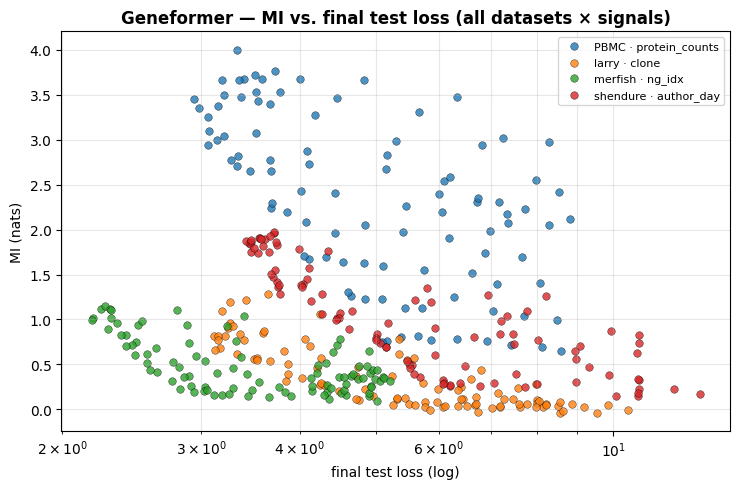

In [25]:
if not df_plot.empty:
    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    palette = plt.get_cmap('tab10')
    for i, ((ds, sig), sub) in enumerate(df_plot.groupby(['dataset', 'signal'])):
        ax.scatter(sub['test_loss'], sub['mi'],
                   color=palette(i % 10), s=30, edgecolor='k', linewidth=0.3,
                   alpha=0.8, label=f'{ds} · {sig}')
    ax.set_xscale('log')
    ax.set_xlabel('final test loss (log)')
    ax.set_ylabel('MI (nats)')
    ax.set_title('Geneformer — MI vs. final test loss (all datasets × signals)',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, which='both')
    ax.legend(fontsize=8, frameon=True, loc='best')
    plt.tight_layout()
    plt.show()